<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [3]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [4]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [5]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [6]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


For the "Median value of owner-occupied homes" provide a boxplot

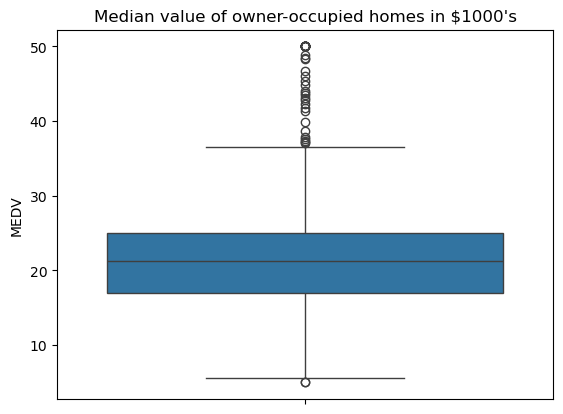

In [22]:
sns.boxplot(boston_df['MEDV'])
pyplot.title("Median value of owner-occupied homes in $1000's")
pyplot.show()

Provide a  bar plot for the Charles river variable

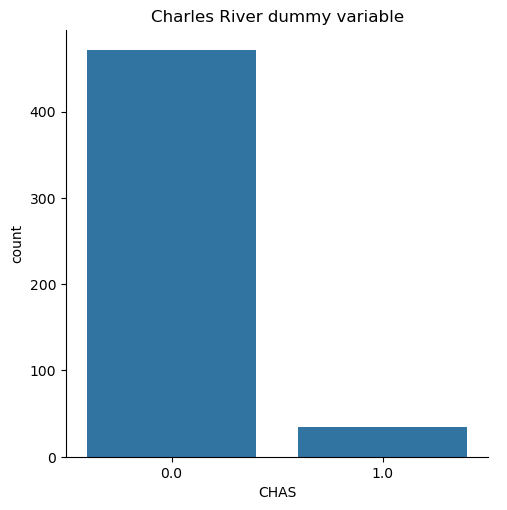

In [21]:
sns.catplot(x='CHAS', kind = 'count', data = boston_df)
pyplot.title('Charles River dummy variable')
pyplot.show()

Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

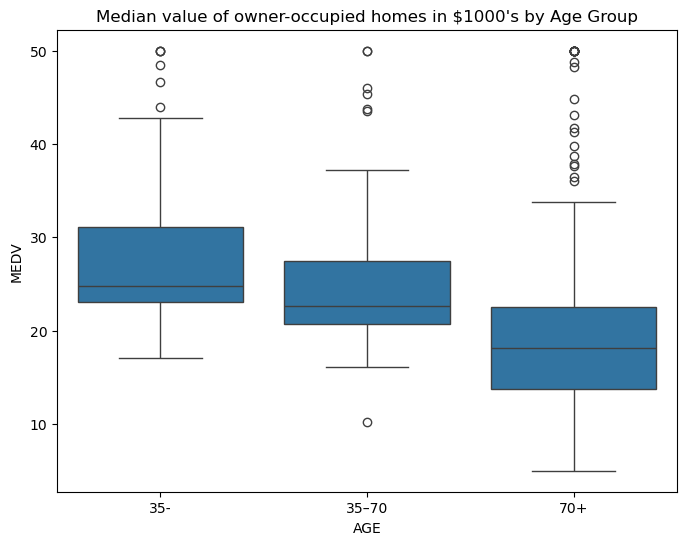

In [20]:
age_bins = [0, 35, 70, float('inf')]
age_labels = ['35-', '35–70', '70+']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=age_bins, labels=age_labels)

pyplot.figure(figsize=(8, 6))
sns.boxplot(x='AGE_group', y='MEDV', data=boston_df)
pyplot.title("Median value of owner-occupied homes in $1000's by Age Group")
pyplot.xlabel('AGE')
pyplot.ylabel('MEDV')
pyplot.show()

Provide a scatter plot to show the relationship between Nitric oxide concentrations (NOX) and the proportion of non-retail business acres per town (INDUS). What can you say about the relationship?

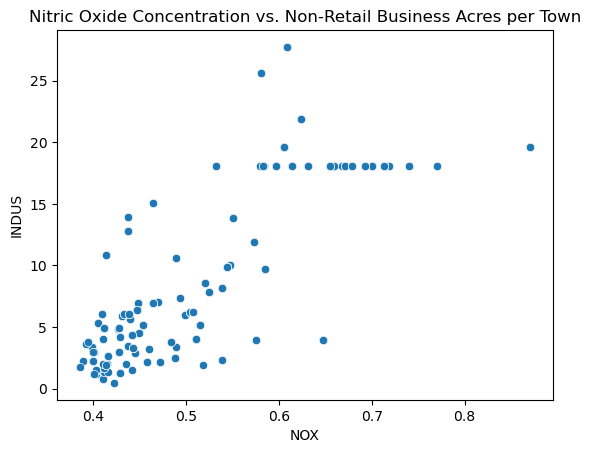

In [18]:
sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
pyplot.title('Nitric Oxide Concentration vs. Non-Retail Business Acres per Town')
pyplot.xlabel('NOX')
pyplot.ylabel('INDUS')
pyplot.show()

Create a histogram for the pupil to teacher ratio variable (PTRATIO)

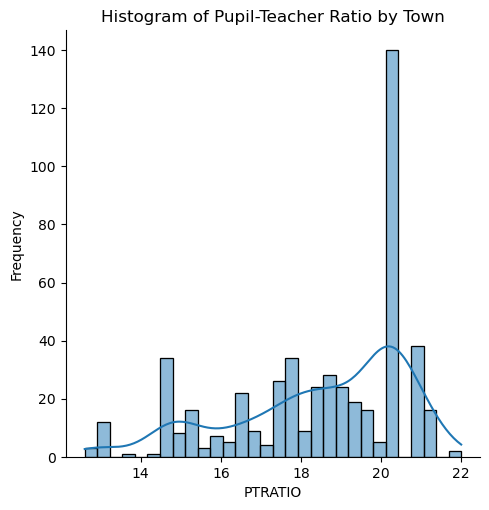

In [17]:
sns.displot(boston_df['PTRATIO'], bins=30, kde=True)
pyplot.title('Histogram of Pupil-Teacher Ratio by Town')
pyplot.xlabel('PTRATIO')
pyplot.ylabel('Frequency')
pyplot.show()

**For each of the following questions:**

- Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)

- Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)

- Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson Correlation)

- What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes? (Regression analysis)

Be sure to:

- State your hypothesis.

- Use α = 0.05

- Perform the test Statistics.

- State the conclusion from the test.

Question 1: Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)
- H0: No difference in median
- H1: There's a difference in median
- alpha: 0.05
- Test type: T-test

In [24]:
# MEDV vs CHAS T-test
chas_yes = boston_df[boston_df['CHAS'] == 1]['MEDV']
chas_no = boston_df[boston_df['CHAS'] == 0]['MEDV']
t_stat, p_value = scipy.stats.ttest_ind(chas_yes, chas_no)
alpha = 0.05
print(f"T-statistic: {t_stat}, P-value: {p_value}")
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in median value of houses bounded by the Charles river.")
else:
    print("Fail to reject the null hypothesis: No significant difference in median value of houses bounded by the Charles river.")


T-statistic: 3.996437466090509, P-value: 7.390623170519905e-05
Reject the null hypothesis: There is a significant difference in median value of houses bounded by the Charles river.


Question 2: Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)
- H0: No difference in median
- H1: There's a difference in median
- alpha: 0.05
- Test type: ANOVA

In [34]:
# MEDV vs AGE ANOVA
model = ols('MEDV ~ C(AGE_group)', data=boston_df).fit(cov_type='HC3')
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
p_value = anova_table['PR(>F)'][0]
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in median value of houses across different age groups.")
else:
    print("Fail to reject the null hypothesis: No significant difference in median value of houses across different age groups.")


                    sum_sq     df          F        PR(>F)
C(AGE_group)   5700.317781    2.0  38.420118  2.966871e-16
Residual      37314.563532  503.0        NaN           NaN
Reject the null hypothesis: There is a significant difference in median value of houses across different age groups.


C:\Users\Minh Ngoc\AppData\Local\Temp\ipykernel_11872\2770914202.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


Question 3: Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson Correlation)

In [31]:
# NOX vs INDUS Pearson
nox = boston_df['NOX']
indus = boston_df['INDUS']

correlation, p_value = scipy.stats.pearsonr(nox, indus)
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print("Reject the null hypothesis: There is a significant correlation between NOX and INDUS.")
else:
    print("Fail to reject the null hypothesis: No significant correlation between NOX and INDUS.")

Pearson correlation coefficient: 0.763651446920915
P-value: 7.913361061241532e-98
Reject the null hypothesis: There is a significant correlation between NOX and INDUS.


Question 4: What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes? (Regression analysis)

In [35]:
# DIS vs MEDV regression analysis
import statsmodels.api as sm
X = boston_df['DIS']
y = boston_df['MEDV']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print('An additional weighted distance to the 5 Boston employment centers is not statistically significant to the median value of owner-occupied homes.')

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        08:52:39   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0